In [ ]:
import pandas as pd
import numpy as np

print("Starting Data Transformation...")

# ==========================================
# 1. EXTRACT: Load the Data
# ==========================================
in_store_df = pd.read_csv('/Users/user/DATA SCIENCE PROJECTS /dsaproject/sales.csv', encoding='latin-1')
online_df = pd.read_json('/Users/user/DATA SCIENCE PROJECTS /online_sales.json')
partner_df = pd.read_csv('/Users/user/DATA SCIENCE PROJECTS /partner_sales.csv')

# ==========================================
# 2. TRANSFORM: In-Store Data
# ==========================================
in_store_df = in_store_df.drop_duplicates()

# Standardize date and add channel
in_store_df['standard_date'] = pd.to_datetime(in_store_df['ORDERDATE']).dt.strftime('%Y-%m-%d')
in_store_df['channel'] = 'In-Store'

# Rename columns to match the final standard
in_store_df = in_store_df.rename(columns={
    'ORDERNUMBER': 'transaction_id',
    'PRODUCTCODE': 'product_id',
    'QUANTITYORDERED': 'quantity',
    'PRICEEACH': 'unit_price',
    'SALES': 'total_amount'
})

# ==========================================
# 3. TRANSFORM: Online Data
# ==========================================
online_df['standard_date'] = pd.to_datetime(online_df['order_timestamp']).dt.strftime('%Y-%m-%d')
online_df['channel'] = 'Online'

online_df = online_df.rename(columns={
    'order_id': 'transaction_id',      # Fixed to match actual JSON key
    'product_code': 'product_id',
    'units_sold': 'quantity',          # Fixed to match actual JSON key
    'price_per_unit': 'unit_price'
})

# Ensure total amount exists
if 'total_amount' not in online_df.columns:
    online_df['total_amount'] = online_df['quantity'] * online_df['unit_price']

# ==========================================
# 4. TRANSFORM: Partner Data
# ==========================================
partner_df['channel'] = 'Partner'

partner_df = partner_df.rename(columns={
    'transaction_no': 'transaction_id',
    'date_of_sale': 'standard_date',
    'item_id': 'product_id',
    'partner_name': 'customer_name'
    # total_amount, unit_price, and quantity are already named correctly in the CSV
})

partner_df['standard_date'] = pd.to_datetime(partner_df['standard_date']).dt.strftime('%Y-%m-%d')

# ==========================================
# 5. INTEGRATE: Combine into one fact Table
# ==========================================
standard_columns = ['transaction_id', 'standard_date', 'product_id', 'quantity', 'unit_price', 'total_amount', 'channel']

# Keep only the columns we need for the data warehouse
in_store_final = in_store_df[standard_columns].copy()
online_final = online_df[standard_columns].copy()
# ensure partner_df has all standard columns (fill missing with NaN) then select
for c in standard_columns:
    if c not in partner_df.columns:
        partner_df[c] = np.nan

partner_final = partner_df[standard_columns].copy()

# Stack them vertically
final_warehouse_data = pd.concat([in_store_final, online_final, partner_final], ignore_index=True)

# ==========================================
# 6. LOAD: Export the clean data
# ==========================================
# Optional: Ensure all data types are clean before exporting
final_warehouse_data['quantity'] = pd.to_numeric(final_warehouse_data['quantity'], errors='coerce')
final_warehouse_data['total_amount'] = pd.to_numeric(final_warehouse_data['total_amount'], errors='coerce')

final_warehouse_data.to_csv('/Users/user/Downloads/cleaned_warehouse_ready_data.csv', index=False)
print("Transformation Complete! The file 'cleaned_warehouse_ready_data.csv' is ready to be loaded into PostgreSQL.")

Starting Data Transformation...
Transformation Complete! The file 'cleaned_warehouse_ready_data.csv' is ready to be loaded into PostgreSQL.


import pandas as pd

# ==========================================
# 1. EXTRACT: Load all three files
# ==========================================
# Note: Update the filenames if yours are named slightly differently!
in_store_df = pd.read_csv('sales.csv')
online_df = pd.read_json('online_sales.json')
partner_df = pd.read_csv('partner_sales.csv') # Use read_excel('partner_sales.xlsx') if it is an Excel file


# ==========================================
# 2. TRANSFORM: Clean the In-Store (CSV) Data
# ==========================================
# Goal: Rename uppercase columns to match our target schema
in_store_df = in_store_df.rename(columns={
    'ORDERNUMBER': 'transaction_id',
    'ORDERDATE': 'standard_date',
    'PRODUCTCODE': 'product_id',
    'QUANTITYORDERED': 'quantity',
    'PRICEEACH': 'unit_price',
    'SALES': 'total_amount'
})
# Standardize the date format to YYYY-MM-DD
in_store_df['standard_date'] = pd.to_datetime(in_store_df['standard_date']).dt.strftime('%Y-%m-%d')
# Add the Channel column
in_store_df['channel'] = 'In-Store'


# ==========================================
# 3. TRANSFORM: Clean the Online (JSON) Data
# ==========================================
# Goal: Rename columns and strip out the weird 'T00:00:00' from the timestamps
online_df = online_df.rename(columns={
    'order_id': 'transaction_id',
    'timestamp': 'standard_date',
    'item_code': 'product_id',
    'qty': 'quantity',
    'price': 'unit_price',
    'total': 'total_amount'
})
# Convert timestamp (e.g., 2012-07-31T00:00:00) into a clean YYYY-MM-DD date
online_df['standard_date'] = pd.to_datetime(online_df['standard_date']).dt.strftime('%Y-%m-%d')
# Add the Channel column
online_df['channel'] = 'Online'


# ==========================================
# 4. TRANSFORM: Clean the Partner (Excel/CSV) Data
# ==========================================
# Goal: Fix column names and calculate the missing 'quantity' column!
partner_df = partner_df.rename(columns={
    'date': 'standard_date',
    'product': 'product_id'
})
# The partner dataset is missing the quantity! We have to calculate it: Total / Unit Price
partner_df['quantity'] = partner_df['total_amount'] / partner_df['unit_price']

# Standardize the date
partner_df['standard_date'] = pd.to_datetime(partner_df['standard_date']).dt.strftime('%Y-%m-%d')
# Add the Channel column
partner_df['channel'] = 'Partner'


# ==========================================
# 5. INTEGRATE: Stack them all together
# ==========================================
# Define the exact columns we want to keep
standard_columns = ['transaction_id', 'standard_date', 'product_id', 'quantity', 'unit_price', 'total_amount', 'channel']

# Filter each dataframe so they ONLY have these 7 columns in the exact same order
in_store_final = in_store_df[standard_columns]
online_final = online_df[standard_columns]
partner_final = partner_df[standard_columns]

# Stack them vertically into one master dataset
final_warehouse_data = pd.concat([in_store_final, online_final, partner_final], ignore_index=True)

# Export to a final CSV that is completely ready for pgAdmin!
final_warehouse_data.to_csv('cleaned_warehouse_ready_data.csv', index=False)
print("Data successfully cleaned, integrated, and saved!")

-- Loading Dimension Tables from Staging
INSERT INTO Dim_Channel (channel_name)
SELECT DISTINCT channel FROM staging_sales WHERE channel IS NOT NULL;

INSERT INTO Dim_Product (product_id)
SELECT DISTINCT product_id FROM staging_sales WHERE product_id IS NOT NULL;

INSERT INTO Dim_Date (date_key, full_date, day, month, year)
SELECT DISTINCT 
    TO_CHAR(standard_date, 'YYYYMMDD')::INT, 
    standard_date,
    EXTRACT(DAY FROM standard_date), 
    EXTRACT(MONTH FROM standard_date),
    EXTRACT(YEAR FROM standard_date)
FROM staging_sales WHERE standard_date IS NOT NULL;

-- Loading Fact Table
INSERT INTO Fact_Sales (transaction_id, date_key, product_key, channel_key, quantity, unit_price, total_amount)
SELECT 
    s.transaction_id,
    TO_CHAR(s.standard_date, 'YYYYMMDD')::INT,
    p.product_key,
    c.channel_key,
    s.quantity,
    s.unit_price,
    s.total_amount
FROM staging_sales s
JOIN Dim_Product p ON s.product_id = p.product_id
JOIN Dim_Channel c ON s.channel = c.channel_name;

-- Dimensional Model (Star Schema) Creation
DROP TABLE IF EXISTS Fact_Sales CASCADE;
DROP TABLE IF EXISTS Dim_Date CASCADE;
DROP TABLE IF EXISTS Dim_Product CASCADE;
DROP TABLE IF EXISTS Dim_Channel CASCADE;

CREATE TABLE Dim_Date (
    date_key INT PRIMARY KEY,
    full_date DATE,
    day INT,
    month INT,
    year INT
);

CREATE TABLE Dim_Product (
    product_key SERIAL PRIMARY KEY,
    product_id VARCHAR(50)
);

CREATE TABLE Dim_Channel (
    channel_key SERIAL PRIMARY KEY,
    channel_name VARCHAR(50)
);

CREATE TABLE Fact_Sales (
    sales_id SERIAL PRIMARY KEY,
    transaction_id VARCHAR(50),
    date_key INT REFERENCES Dim_Date(date_key),
    product_key INT REFERENCES Dim_Product(product_key),
    channel_key INT REFERENCES Dim_Channel(channel_key),
    quantity NUMERIC,
    unit_price NUMERIC,
    total_amount NUMERIC
);


-- 1. Indexing for faster lookups
CREATE INDEX idx_fact_date ON Fact_Sales(date_key);
CREATE INDEX idx_fact_channel ON Fact_Sales(channel_key);
CREATE INDEX idx_fact_product ON Fact_Sales(product_key);

-- 2. Materialized View for pre-aggregated dashboard data
CREATE MATERIALIZED VIEW mv_monthly_channel_sales AS
SELECT 
    d.year, 
    d.month, 
    c.channel_name, 
    SUM(f.total_amount) as total_revenue
FROM Fact_Sales f
JOIN Dim_Date d ON f.date_key = d.date_key
JOIN Dim_Channel c ON f.channel_key = c.channel_key
GROUP BY d.year, d.month, c.channel_name;

-- 3. Partitioning Example (Breaking the fact table by year)
-- Note: This is a structural demonstration of how the table would be partitioned.
CREATE TABLE Fact_Sales_Partitioned (
    sales_id SERIAL,
    transaction_id VARCHAR(50),
    date_key INT,
    product_key INT,
    channel_key INT,
    quantity NUMERIC,
    unit_price NUMERIC,
    total_amount NUMERIC
) PARTITION BY RANGE (date_key);

CREATE TABLE sales_2023 PARTITION OF Fact_Sales_Partitioned FOR VALUES FROM (20230101) TO (20240101);
CREATE TABLE sales_2024 PARTITION OF Fact_Sales_Partitioned FOR VALUES FROM (20240101) TO (20250101);

In [4]:
# ==========================================
# 4. INTEGRATE: Combine Heterogeneous Datasets
# ==========================================
# Define the final standard columns we want to keep for the warehouse
standard_columns = ['transaction_id', 'standard_date', 'product_id', 'quantity', 'unit_price', 'total_amount', 'channel']

# Ensure all dataframes have exactly these columns to prevent mismatch errors
in_store_final = in_store_df[standard_columns].copy()
online_final = online_df[standard_columns].copy()
partner_final = partner_df[standard_columns].copy()

# Stack them all vertically into one single, integrated dataset
final_warehouse_data = pd.concat([in_store_final, online_final, partner_final], ignore_index=True)

# Export the integrated data to a single CSV for PostgreSQL ingestion
final_warehouse_data.to_csv('cleaned_warehouse_ready_data.csv', index=False)

-- 1. ROLL-UP (Summarizing Month to Year)
SELECT d.year, SUM(f.total_amount) AS yearly_revenue
FROM Fact_Sales f JOIN Dim_Date d ON f.date_key = d.date_key
GROUP BY ROLLUP (d.year) ORDER BY d.year;

-- 2. DRILL-DOWN (Breaking down Year into Months)
SELECT d.year, d.month, SUM(f.total_amount) AS monthly_revenue
FROM Fact_Sales f JOIN Dim_Date d ON f.date_key = d.date_key
WHERE d.year = 2024 
GROUP BY d.year, d.month ORDER BY d.month;

-- 3. SLICE (Filtering by one dimension: Online only)
SELECT p.product_id, SUM(f.total_amount) AS total_revenue
FROM Fact_Sales f JOIN Dim_Product p ON f.product_key = p.product_key
JOIN Dim_Channel c ON f.channel_key = c.channel_key
WHERE c.channel_name = 'Online'
GROUP BY p.product_id ORDER BY total_revenue DESC;

-- 4. DICE (Filtering by two dimensions: Online AND 2024)
SELECT p.product_id, SUM(f.total_amount) AS total_revenue
FROM Fact_Sales f JOIN Dim_Product p ON f.product_key = p.product_key
JOIN Dim_Channel c ON f.channel_key = c.channel_key
JOIN Dim_Date d ON f.date_key = d.date_key
WHERE c.channel_name = 'Online' AND d.year = 2024
GROUP BY p.product_id ORDER BY total_revenue DESC;

-- =======================================================
-- PERFORMANCE EVALUATION
-- Comparing query execution time before and after optimization
-- =======================================================

-- TEST 1: BEFORE OPTIMIZATION (Raw Fact Table Query)
-- This forces the database to read thousands of rows and do the math on the fly.
EXPLAIN ANALYZE 
SELECT 
    d.year, 
    d.month, 
    c.channel_name, 
    SUM(f.total_amount) as total_revenue
FROM Fact_Sales f
JOIN Dim_Date d ON f.date_key = d.date_key
JOIN Dim_Channel c ON f.channel_key = c.channel_key
GROUP BY d.year, d.month, c.channel_name;


-- TEST 2: AFTER OPTIMIZATION (Materialized View Query)
-- This queries the pre-calculated view, which should run drastically faster.
EXPLAIN ANALYZE 
SELECT * FROM mv_monthly_channel_sales;

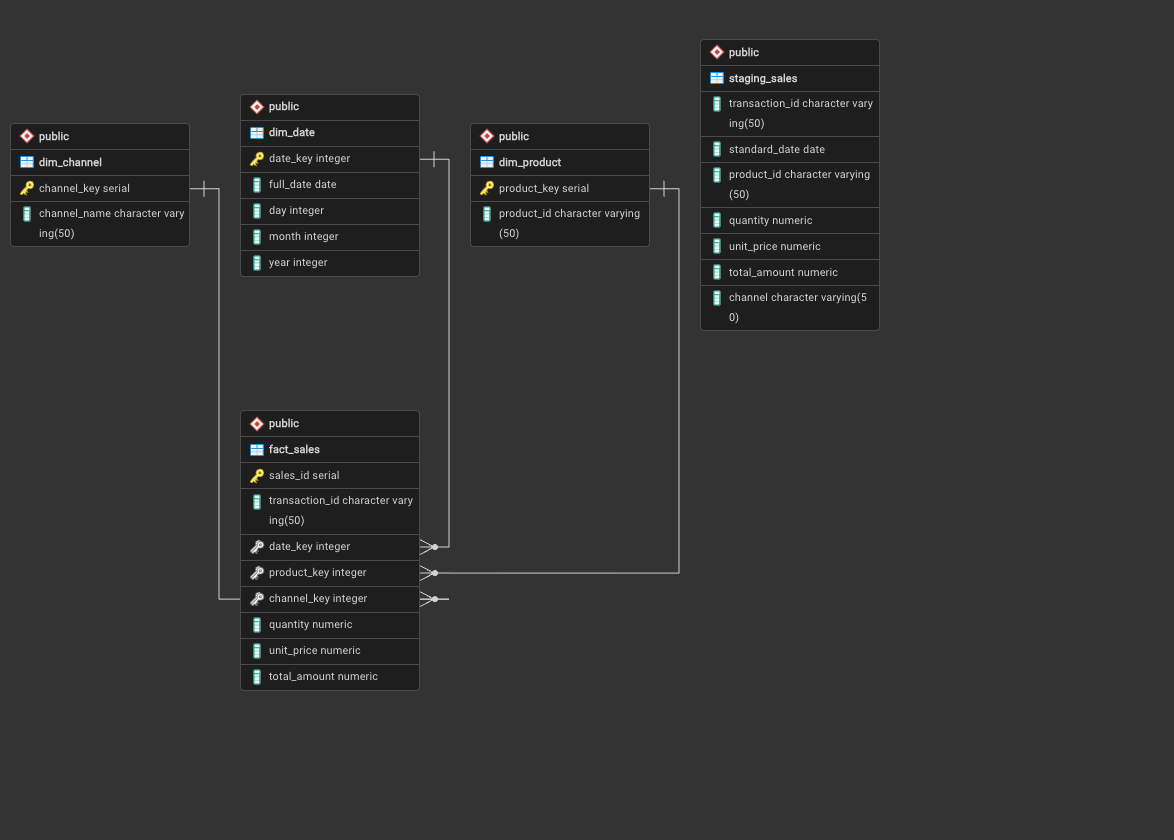

In [ ]:
#ERD DIAGRAM  
from IPython.display import Image, display

display(Image("/Users/user/DATA SCIENCE PROJECTS /dsaproject/image.png"))